In [1]:
# !pip install opencv-python scikit-image scikit-learn tensorflow keras matplotlib pandas numpy h5py

In [2]:
# !python -m pip install --upgrade pip

In [1]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"  # oneDNN's Conv2DTranspose gradient primitive
# crashes with AbortedError on some CPUs -- must be set before tensorflow is imported.

import h5py
import gc
from glob import glob
import numpy as np
from matplotlib import pylab as plt
import cv2
import tensorflow as tf
print(tf.__version__)
from  tensorflow.keras.layers import *
from tensorflow.keras.initializers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import Model
from skimage import exposure
from sklearn.preprocessing import StandardScaler
import time
from sklearn.model_selection import train_test_split
import joblib
from matplotlib import pyplot

2.21.0


In [2]:
dataset = h5py.File('train.h5', 'r')
X = dataset["x"]
y = dataset["y"]

X.shape, y.shape



((9245, 256, 256, 6), (9245, 256, 256, 6))

In [3]:
def contrast(image):
    for band_idx in range(image.shape[-1]):
        band_data = image[:,:,band_idx]
        valid_data = band_data[np.logical_and(band_data != np.inf, band_data != -np.inf)]
        in_low, in_high = np.percentile(valid_data, (2, 98))
        
        band_data = exposure.rescale_intensity(band_data, in_range=(in_low, in_high))
        image[:,:,band_idx] = band_data
        
    return image


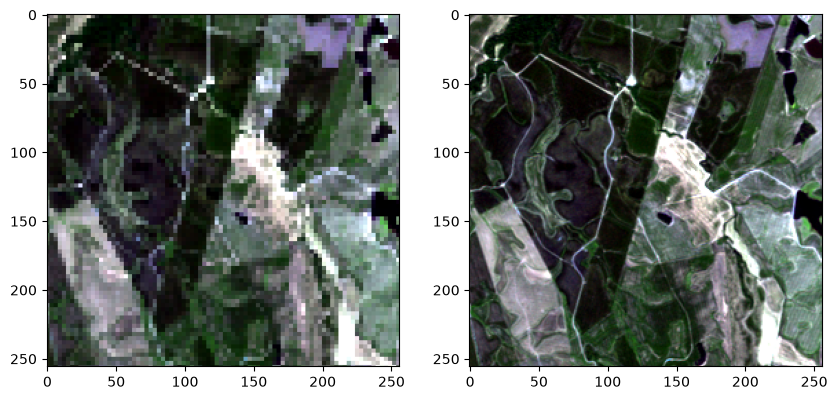

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(10, 8))

axs[0].imshow(contrast(X[125][:,:, :3] / 10000))
axs[1].imshow(contrast(y[125][:,:, :3] / 10000))


In [5]:

def load_data(batch_size):
    i=np.random.randint(0,int(len(X)/batch_size))
    
    img_A=(np.array(X[i:i+batch_size]) / 5000.0) - 1
    img_B=(np.array(y[i:i+batch_size]) / 5000.0) - 1

    return img_A,img_B

def load_batch(batch_size):
    
    for i in range(int(len(X)/batch_size)):
        img_A=(X[i:i+batch_size] / 5000.0) - 1
        img_B=(y[i:i+batch_size] / 5000.0) - 1

        yield img_A,img_B



In [6]:
def define_discriminator(image_shape):
    # weight initialization
    init = RandomNormal(stddev=0.02)
    # source image input
    in_src_image = Input(shape=image_shape)
    # target image input
    in_target_image = Input(shape=image_shape)
    # concatenate images channel-wise
    merged = Concatenate()([in_src_image, in_target_image])
    # C64
    d = Conv2D(64, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(merged)
    d = LeakyReLU(negative_slope=0.2)(d)
    # C128
    d = Conv2D(128, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
    d = BatchNormalization()(d)
    d = LeakyReLU(negative_slope=0.2)(d)
    # C256
    d = Conv2D(256, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
    d = BatchNormalization()(d)
    d = LeakyReLU(negative_slope=0.2)(d)
    # C512
    d = Conv2D(512, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
    d = BatchNormalization()(d)
    d = LeakyReLU(negative_slope=0.2)(d)
    # second last output layer
    d = Conv2D(512, (4,4), padding='same', kernel_initializer=init)(d)
    d = BatchNormalization()(d)
    d = LeakyReLU(negative_slope=0.2)(d)
    # patch output
    d = Conv2D(1, (4,4), padding='same', kernel_initializer=init)(d)
    patch_out = Activation('sigmoid')(d)
    # define model
    model = Model([in_src_image, in_target_image], patch_out)
    # compile model
    opt = Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt, loss_weights=[0.5])
    return model

In [7]:
def define_encoder_block(layer_in, n_filters, batchnorm=True):
    # weight initialization
    init = RandomNormal(stddev=0.02)
    # add downsampling layer
    g = Conv2D(n_filters, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(layer_in)
    # conditionally add batch normalization
    if batchnorm:
        g = BatchNormalization()(g, training=True)
    # leaky relu activation
    g = LeakyReLU(negative_slope=0.2)(g)
    return g

# define a decoder block
def decoder_block(layer_in, skip_in, n_filters, dropout=True):
    # weight initialization
    init = RandomNormal(stddev=0.02)
    # add upsampling layer -- UpSampling2D + Conv2D instead of Conv2DTranspose:
    # Conv2DTranspose's backward pass (Conv2DBackpropFilter) crashes with an
    # AbortedError under oneDNN on some CPUs. This is equivalent (fixed 2x
    # upsample, then a learned conv) and avoids that op entirely.
    g = UpSampling2D(size=(2,2))(layer_in)
    g = Conv2D(n_filters, (4,4), padding='same', kernel_initializer=init)(g)
    # add batch normalization
    g = BatchNormalization()(g, training=True)
    # conditionally add dropout
    if dropout:
        g = Dropout(0.5)(g, training=True)
    # merge with skip connection
    g = Concatenate()([g, skip_in])
    # relu activation
    g = Activation('relu')(g)
    return g

# define the standalone generator model
def define_generator(image_shape):
    # weight initialization
    init = RandomNormal(stddev=0.02)
    # image input
    in_image = Input(shape=image_shape)
    # encoder model
    e1 = define_encoder_block(in_image, 64, batchnorm=False)
    e2 = define_encoder_block(e1, 128)
    e3 = define_encoder_block(e2, 256)
    e4 = define_encoder_block(e3, 512)
    e5 = define_encoder_block(e4, 512)
    e6 = define_encoder_block(e5, 512)
    e7 = define_encoder_block(e6, 512)
    # bottleneck, no batch norm and relu
    b = Conv2D(512, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(e7)
    b = Activation('relu')(b)
    # decoder model
    d1 = decoder_block(b, e7, 512)
    d2 = decoder_block(d1, e6, 512)
    d3 = decoder_block(d2, e5, 512)
    d4 = decoder_block(d3, e4, 512, dropout=False)
    d5 = decoder_block(d4, e3, 256, dropout=False)
    d6 = decoder_block(d5, e2, 128, dropout=False)
    d7 = decoder_block(d6, e1, 64, dropout=False)
    # output -- same UpSampling2D + Conv2D swap as decoder_block, for the
    # same reason (avoids the crashing Conv2DTranspose gradient op)
    g = UpSampling2D(size=(2,2))(d7)
    g = Conv2D(image_shape[-1], (4,4), padding='same', kernel_initializer=init)(g)
    out_image = Activation('tanh')(g)
    # define model
    model = Model(in_image, out_image)
    return model

In [8]:
def define_gan(g_model, d_model, image_shape):
    # make weights in the discriminator not trainable
    for layer in d_model.layers:
        if not isinstance(layer, BatchNormalization):
            layer.trainable = False
    # define the source image
    in_src = Input(shape=image_shape)
    # connect the source image to the generator input
    gen_out = g_model(in_src)
    # connect the source input and generator output to the discriminator input
    dis_out = d_model([in_src, gen_out])
    # src image as input, generated image and classification output
    model = Model(in_src, [dis_out, gen_out])
    # compile model
    opt = Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss=['binary_crossentropy', 'mae'], optimizer=opt, loss_weights=[1,100])
    return model

In [9]:
# select a batch of random samples, returns images and target
def generate_real_samples(n_samples, patch_shape):
    # unpack dataset
    trainA, trainB = load_data(n_samples)
    # choose random instances
    ix = np.random.randint(0, trainA.shape[0], n_samples)
    # retrieve selected images
    X1, X2 = trainA[ix], trainB[ix]
    # generate 'real' class labels (1)
    y = np.ones((n_samples, patch_shape, patch_shape, 1))
    return [X1, X2], y

In [10]:
# generate a batch of images, returns images and targets
def generate_fake_samples(g_model, samples, patch_shape):
    # generate fake instance
    X = g_model.predict(samples)
    # create 'fake' class labels (0)
    y = np.zeros((len(X), patch_shape, patch_shape, 1))
    return X, y



In [11]:
def summarize_performance(step, g_model, logs_dir, n_samples):
    r, c = 3, n_samples
    
    # select a sample of input images
    [X_realA, X_realB], _ = generate_real_samples(n_samples, 1)
    
    # generate a batch of fake samples
    X_fakeB, _ = generate_fake_samples(g_model, X_realA, 1)
    
    gen_imgs = np.concatenate([X_realA, X_fakeB, X_realB])

    titles = ['Condition', 'Generated', 'Original']
    fig, axs = plt.subplots(r, c, figsize=(20,20))
    cnt = 0
    for i in range(r):
        for j in range(c):
            image = gen_imgs[cnt]

            reescaled_image = (image + 1) * 5000

            rgb_image = reescaled_image[:,:, :3]

            axs[i,j].imshow(contrast(rgb_image/10000))
            axs[i,j].set_title(titles[i])
            axs[i,j].axis('off')
            cnt += 1
            
    filename = '%s/plot_%06d.png' % (logs_dir, step)
    fig.savefig(filename)
    plt.show()

In [12]:
 #train pix2pix model
def train(d_model, g_model, gan_model, n_epochs, n_batch, logs_dir, d_filename, g_filename):
    
    # determine the output square shape of the discriminator
    n_patch = d_model.output_shape[1]
    
    # unpack dataset
    for epoch in range(1, n_epochs + 1):
        for batch_i,(trainA,trainB) in enumerate(load_batch(n_batch)):
            
            # select a batch of real samples
            [X_realA, X_realB], y_real = generate_real_samples(n_batch, n_patch)

            # generate a batch of fake samples
            X_fakeB, y_fake = generate_fake_samples(g_model, X_realA, n_patch)
            
            # update discriminator for real samples
            d_loss1 = d_model.train_on_batch([X_realA, X_realB], y_real)
            
            # update discriminator for generated samples
            d_loss2 = d_model.train_on_batch([X_realA, X_fakeB], y_fake)
            
            # update the generator
            g_loss, _, _ = gan_model.train_on_batch(X_realA, [y_real, X_realB])
            
            # summarize performance
            print(f'[Epoch {epoch}] [Batch {batch_i}] [D1 loss: {d_loss1}] [D2 loss: {d_loss2}] [G loss: {g_loss}]')
        
        # summarize model performance
        summarize_performance(epoch, g_model, logs_dir, n_samples=3)
        # save the generator model
        g_model.save(d_filename)

        # save the discriminator model        
        d_model.save(d_filename)

In [ ]:
# load image data
image_shape = (256, 256, 6)

# define the models
d_model = define_discriminator(image_shape)
g_model = define_generator(image_shape)

# save or reload models
logs_dir = 'logs'
if not os.path.exists(logs_dir):
    os.mkdir(logs_dir)

g_filename = f'{logs_dir}/g_model.h5'
d_filename = f'{logs_dir}/d_model.h5'

if os.path.exists(g_filename):
    g_model.load_model(g_filename)
    
if os.path.exists(d_filename):
    d_model.load_model(d_filename)

# define the composite model
gan_model = define_gan(g_model, d_model, image_shape)

# train model
train(d_model, g_model, gan_model, n_epochs=20, n_batch=32, 
      logs_dir=logs_dir, d_filename=d_filename, g_filename=g_filename)

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
[Epoch 1] [Batch 0] [D1 loss: 0.5956893563270569] [D2 loss: 0.27623459696769714] [G loss: 66.50816345214844]
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
[Epoch 1] [Batch 1] [D1 loss: 0.5974469184875488] [D2 loss: 0.2769549489021301] [G loss: 57.20317840576172]
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
[Epoch 1] [Batch 2] [D1 loss: 0.5903636813163757] [D2 loss: 0.2788895070552826] [G loss: 47.26338577270508]
1/1 ━━━━━━━━━━━━━━━━━━━━ 48s 48s/step
